<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ?
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [ ]:
#Importation de la librairie Pandas
import pandas as pd
#Importation de la librairie Numpy
import numpy as np
#Importation de la librairie Matplotlib
import matplotlib.pyplot as plt
#Importation de la librairie Seaborn
import seaborn as sns

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [ ]:
#Importation du fichier population.csv
population = pd.read_csv('population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))
print("Le tableau comporte {} observation(s) et colonne(s)".format(population.shape))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)
Le tableau comporte (1416, 3) observation(s) et colonne(s)


In [ ]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1416 entries, 0 to 1415
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Zone    1416 non-null   object 
 1   Année   1416 non-null   int64  
 2   Valeur  1416 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 33.3+ KB


In [ ]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [ ]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
##Les données de Valeur dans populations sont en milliers d'habitants donc en faisant  *1000 j'aurais le nombre d'habitants
population['Valeur']=population['Valeur']*1000

In [ ]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={'Valeur':'Population'},inplace=True)


In [ ]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
dispo_alimentaire.shape

(15605, 18)

In [ ]:
#Consulter le nombre de colonnes
dispo_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  object 
 1   Produit                                                        15605 non-null  object 
 2   Origine                                                        15605 non-null  object 
 3   Aliments pour animaux                                          2720 non-null   float64
 4   Autres Utilisations                                            5496 non-null   float64
 5   Disponibilité alimentaire (Kcal/personne/jour)                 14241 non-null  float64
 6   Disponibilité alimentaire en quantité (kg/personne/an)         14015 non-null  float64
 7   Disponibilité de matière grasse en quantité (g/personne/jo

In [ ]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0,inplace=True)


In [ ]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
## 1tonne = 1 000kgs, donc 1 000 tonnes = 1 000 000 kgs (soit 1 MILLION DE KGS)
## je multiplie donc par 1 000 000
colonnes_a_multiplier = ['Aliments pour animaux', 'Autres Utilisations' ,'Exportations - Quantité', 'Importations - Quantité', 'Nourriture', 'Pertes','Production','Semences','Traitement','Variation de stock']
dispo_alimentaire.loc[:, colonnes_a_multiplier] *= 1000000

In [ ]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
aide_alimentaire.shape

(1475, 4)

In [ ]:
#Consulter le nombre de colonnes
aide_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Pays bénéficiaire  1475 non-null   object
 1   Année              1475 non-null   int64 
 2   Produit            1475 non-null   object
 3   Valeur             1475 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 46.2+ KB


In [ ]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [ ]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'},inplace=True)

In [ ]:
#Multiplication de la colonne valeur d'Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire.loc[:, 'Valeur'] *= 1000

In [ ]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [ ]:
#Afficher les dimensions du dataset
sous_nutrition.shape

(1218, 3)

In [ ]:
#Consulter le nombre de colonnes
sous_nutrition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Zone    1218 non-null   object
 1   Année   1218 non-null   object
 2   Valeur  624 non-null    object
dtypes: object(3)
memory usage: 28.7+ KB


In [ ]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [ ]:
#Conversion de la colonne sous nutrition en numérique
#sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

In [ ]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'], errors='coerce')
sous_nutrition.fillna(0,inplace=True)

In [ ]:
#changement du nom de la colonne Valeur par sous_nutrition
##j'ai mis sous nutrition a la place de sous_nutrition sinon c'est le meme nom que le df
sous_nutrition.rename(columns={'Valeur':'sous nutrition'},inplace=True)

In [ ]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous nutrition']=sous_nutrition['sous nutrition']*1000000


In [ ]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,sous nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [ ]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017

##filtrer le df population pour l'année 2017
population2017= population[population['Année'] == 2017]

##modifier les années du df sous_nutriton qui sont sous forme 2016-2018
sous_nutrition['Année'] = sous_nutrition['Année'].str.split('-').str[0].astype(int) + 1
##filtrer le df sous_nutrition pour l'année 2017
sous_nutrition2017= sous_nutrition[sous_nutrition['Année'] == 2017]

##jointure entre population2017 et sous_nutrition2017
joinpopssnut2017= pd.merge(population2017, sous_nutrition2017, on=['Zone'], how='outer', indicator='merge')
##affichage des resultats de merge
display(joinpopssnut2017['merge'].value_counts())


,count
merge,
both,203
left_only,33
right_only,0


In [ ]:
#Affichage du dataset
display(joinpopssnut2017)


,Zone,Année_x,Population,Année_y,sous nutrition,merge
0,Afghanistan,2017,36296113.0,2017.0,10500000.0,both
1,Afrique du Sud,2017,57009756.0,2017.0,3100000.0,both
2,Albanie,2017,2884169.0,2017.0,100000.0,both
3,Algérie,2017,41389189.0,2017.0,1300000.0,both
4,Allemagne,2017,82658409.0,2017.0,0.0,both
...,...,...,...,...,...,...
231,Îles Salomon,2017,636039.0,2017.0,0.0,both
232,Îles Turques-et-Caïques,2017,37115.0,NaN,NaN,left_only
233,Îles Vierges américaines,2017,104751.0,NaN,NaN,left_only
234,Îles Vierges britanniques,2017,29577.0,NaN,NaN,left_only


In [ ]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
somme_ssnut2017= joinpopssnut2017['sous nutrition'].sum()
print(f'En 2017, {somme_ssnut2017} sont en état de sous nutrition, soit 535.7 millions de personnes.')

##calcul de la proportion
print(f'La proportion de personnes en sous nutrition est de {(somme_ssnut2017/joinpopssnut2017["Population"].sum()):.2%}')

En 2017, 535700000.0 sont en état de sous nutrition, soit 535.7 millions de personnes.
La proportion de personnes en sous nutrition est de 7.10%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [ ]:
#Combien mange en moyenne un être humain ? Source => https://www.vidal.fr/sante/nutrition/equilibre-alimentaire-adulte/recommandations-nutritionnelles-adulte.html#:~:text=Pour%20un%20homme%20adulte%2C%20l,800%20%C3%A0%202%20200%20calories.
#hommes besoins entre 2400 et 2600 -> moyenne homme = 2500
#femmes besoins entre 1800 et 2200 -> moyenne femme = 2000
#moyenne humains = 2250
print("En moyenne, un humain mange 2250kcal par jour")

En moyenne, un humain mange 2250kcal par jour


In [ ]:
population2017.info()
dispo_alimentaire.info()

<class 'pandas.core.frame.DataFrame'>
Index: 236 entries, 4 to 1414
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Zone        236 non-null    object 
 1   Année       236 non-null    int64  
 2   Population  236 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 7.4+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15605 entries, 0 to 15604
Data columns (total 18 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   Zone                                                           15605 non-null  object 
 1   Produit                                                        15605 non-null  object 
 2   Origine                                                        15605 non-null  object 
 3   Aliments pour animaux                                      

In [ ]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
##right car dans les questions suivantes on me demande le nombre de calories
joinpopdispo= pd.merge(population2017, dispo_alimentaire, on=['Zone'], how='right', indicator='merge')

In [ ]:
#Affichage du nouveau dataframe
display(joinpopdispo)

,Zone,Année,Population,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),...,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,merge
0,Afghanistan,2017.0,36296113.0,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,...,53.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,both
1,Afghanistan,2017.0,36296113.0,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,...,41.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,both
2,Afghanistan,2017.0,36296113.0,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,...,2.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,both
3,Afghanistan,2017.0,36296113.0,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
4,Afghanistan,2017.0,36296113.0,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,...,82.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,2017.0,636039.0,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,...,3.0,0.0,0.0,3000000.0,0.0,2000000.0,0.0,0.0,0.0,both
15601,Îles Salomon,2017.0,636039.0,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,...,2.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,both
15602,Îles Salomon,2017.0,636039.0,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both
15603,Îles Salomon,2017.0,636039.0,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,both


In [ ]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
joinpopdispo['dispo_kcal']=joinpopdispo['Disponibilité alimentaire (Kcal/personne/jour)']*joinpopdispo['Population']


In [ ]:
#Calcul du nombre d'humains pouvant être nourris
nbkcaldispo = joinpopdispo['dispo_kcal'].sum()
print(f"En 2017, {nbkcaldispo:,.0f} kcal sont disponibles dans le monde, soit 20 918 milliards")


nbhumainsnourris = joinpopdispo['dispo_kcal'].sum() / 2250
print("Donc, {} humains peuvent être nourris,".format(round(nbhumainsnourris, 2)))

prophumainsnourris= nbhumainsnourris / population2017['Population'].sum() * 100

print("ce qui correspond à, {}% des humains.".format(round(prophumainsnourris, 2)))


En 2017, 20,918,984,627,331 kcal sont disponibles dans le monde, soit 20 918 milliards
Donc, 9297326501.04 humains peuvent être nourris,
ce qui correspond à, 123.17% des humains.


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [ ]:
#Transfert des données avec les végétaux dans un nouveau dataframe
vegetaux= joinpopdispo[joinpopdispo['Origine'] == 'vegetale']


In [ ]:
#Calcul du nombre de kcal disponible pour les végétaux
kcalvegetaux= vegetaux['dispo_kcal'].sum()
print(f"En 2017, {kcalvegetaux:,.0f} kcals sont disponibles grâce aux vegetaux, soit 17 260 milliards")

En 2017, 17,260,764,211,501 kcals sont disponibles grâce aux vegetaux, soit 17 260 milliards


In [ ]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
humveg= kcalvegetaux/2250
prophumveg= humveg / population2017['Population'].sum() * 100
print(f"En 2017, {humveg:,.0f}, humains (soit 7 671 millions) peuvent être nourris par des vegetaux, ce qui correspond à {prophumveg:,.1f}%")

En 2017, 7,671,450,761, humains (soit 7 671 millions) peuvent être nourris par des vegetaux, ce qui correspond à 101.6%


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [ ]:
#Calcul de la disponibilité totale
##elle correspond a la disponibilité interieure
dispototale= dispo_alimentaire['Disponibilité intérieure'].sum()
print("En 2017, la disponibilité totale mondiale est de {:,.0f} kcal, soit 9,845 millions.".format(dispototale))

En 2017, la disponibilité totale mondiale est de 9,848,994 kcal, soit 9,845 millions.


La somme de Aliments pour animaux est de 1304245000000 kcal
La somme de Pertes est de 453698000000 kcal
La somme de Nourriture est de 4876258000000 kcal
La somme de Autres Utilisations est de 865023000000 kcal
La somme de Semences est de 154681000000 kcal
La somme de Traitement est de 2204687000000 kcal
Part de Aliments pour animaux par rapport à la disponibilité intérieure : 13.24%
Part de Pertes par rapport à la disponibilité intérieure : 4.61%
Part de Nourriture par rapport à la disponibilité intérieure : 49.51%
Part de Autres Utilisations par rapport à la disponibilité intérieure : 8.78%
Part de Semences par rapport à la disponibilité intérieure : 1.57%
Part de Traitement par rapport à la disponibilité intérieure : 22.38%


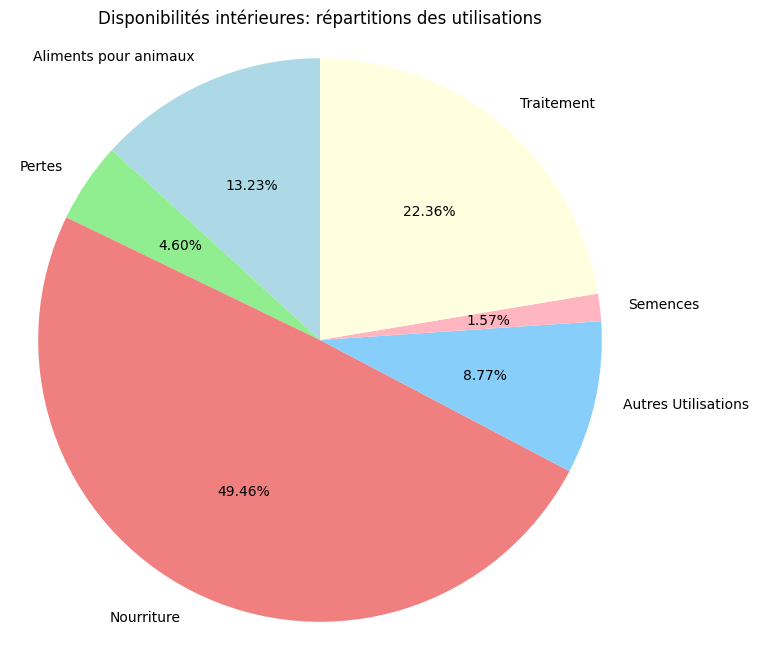

In [ ]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures,

##Liste des variables à analyser
liste = ['Aliments pour animaux', 'Pertes', 'Nourriture', 'Autres Utilisations', 'Semences', 'Traitement']

##Dictionnaire pour stocker les totaux
totaux = {}

##Calcul des sommes pour chaque variable dans la liste
for variable in liste:
    totaux[variable] = dispo_alimentaire[variable].sum()
    print(f"La somme de {variable} est de {totaux[variable]:.0f} kcal")

##Dictionnaire pour stocker les parts en pourcentage
parts = {}

##Calcul des parts pour chaque variable par rapport à dispo_totalemondiale2017
for variable in liste:
    parts[variable] = (totaux[variable] / dispototale)  *100

##Affichage des résultats
for variable in liste:
    print(f"Part de {variable} par rapport à la disponibilité intérieure : {parts[variable]/1000000:.2f}%")

## creation du graphique camembert
plt.figure(figsize=(8, 8))
plt.pie(parts.values(), labels=parts.keys(), autopct='%1.2f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue', 'lightpink', 'lightyellow'])
plt.title('Disponibilités intérieures: répartitions des utilisations')
plt.axis('equal')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [ ]:
#Création d'une liste avec toutes les variables
listecereales = ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigle","Avoine", "Millet", "Sorgho", "Céréales, Autres"]

In [ ]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
cereales= dispo_alimentaire[dispo_alimentaire['Produit'].isin(listecereales)]

La somme de Aliments pour animaux est de 873535000000 kcal
La somme de Pertes est de 107120000000 kcal
La somme de Nourriture est de 1029010000000 kcal
La somme de Autres Utilisations est de 234787000000 kcal
La somme de Semences est de 68538000000 kcal
La somme de Traitement est de 94589000000 kcal
Part de Aliments pour animaux par rapport aux dispo totales cereales : 36.29%
Part de Pertes par rapport aux dispo totales cereales : 4.45%
Part de Nourriture par rapport aux dispo totales cereales : 42.75%
Part de Autres Utilisations par rapport aux dispo totales cereales : 9.75%
Part de Semences par rapport aux dispo totales cereales : 2.85%
Part de Traitement par rapport aux dispo totales cereales : 3.93%


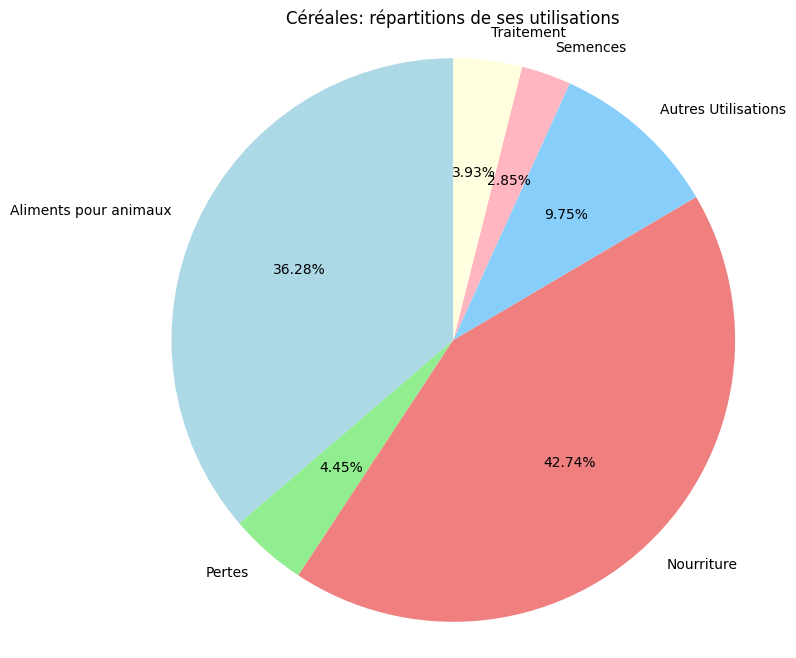

In [ ]:
#Affichage de la proportion d'alimentation animale

##calcul des dispo totales de cereales
dispocer=cereales['Disponibilité intérieure'].sum()

##on a deja liste = ['Aliments pour animaux', 'Pertes', 'Nourriture', 'Autres Utilisations', 'Semences', 'Traitement']

##Dictionnaire pour stocker les totaux
totaux = {}

##Calcul des sommes pour chaque variable dans la liste
for variable in liste:
  totaux[variable] = cereales[variable].sum()
  print(f"La somme de {variable} est de {totaux[variable]:.0f} kcal")

##Dictionnaire pour stocker les parts
parts={}

##calcul des parts pour chaque variable de la liste
for variable in liste:
  parts[variable] = (totaux[variable] / dispocer)  *100
  print(f"Part de {variable} par rapport aux dispo totales cereales : {parts[variable]/1000000:.2f}%")

## creation du graphique camembert
plt.figure(figsize=(8, 8))
plt.pie(parts.values(), labels=parts.keys(), autopct='%1.2f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral', 'lightskyblue', 'lightpink', 'lightyellow'])
plt.title('Céréales: répartitions de ses utilisations')
plt.axis('equal')
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [ ]:
#Création de la colonne proportion par pays
joinpopssnut2017['proportion par pays'] = (joinpopssnut2017['sous nutrition'] / joinpopssnut2017['Population'])*100


In [ ]:
#affichage après trie des 10 pires pays
pires_pays= joinpopssnut2017.sort_values(by='proportion par pays', ascending=False).head(10)
display(pires_pays[['Zone','proportion par pays']])

,Zone,proportion par pays
81,Haïti,48.259182
165,République populaire démocratique de Corée,47.188685
109,Madagascar,41.062924
104,Libéria,38.279742
100,Lesotho,38.249438
197,Tchad,37.957606
157,Rwanda,35.055619
126,Mozambique,32.810898
200,Timor-Leste,32.173531
0,Afghanistan,28.928718


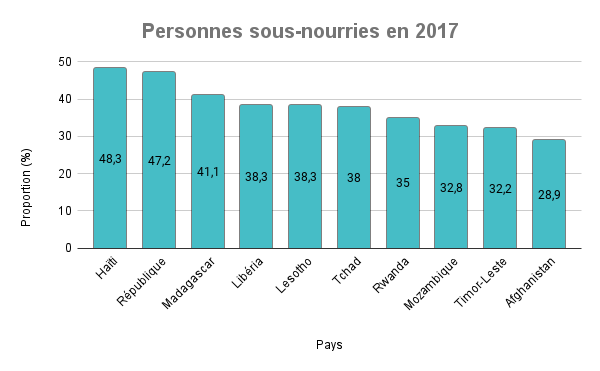

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [ ]:
#calcul du total de l'aide alimentaire par pays
aides= aide_alimentaire.groupby('Zone')['Valeur'].sum()


In [ ]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
display(aides.sort_values(ascending=False).head(10))


,Valeur
Zone,
République arabe syrienne,1858943000
Éthiopie,1381294000
Yémen,1206484000
Soudan du Sud,695248000
Soudan,669784000
Kenya,552836000
Bangladesh,348188000
Somalie,292678000
République démocratique du Congo,288502000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [ ]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année
aidesalimentaires = aide_alimentaire.groupby(['Zone', 'Année'])['Valeur'].sum().unstack()
print(aidesalimentaires)

aidesalimentaires['Total'] = aidesalimentaires.sum(axis=1)

Année               2013         2014         2015       2016
Zone                                                         
Afghanistan  128238000.0   57214000.0          NaN        NaN
Algérie       35234000.0   18980000.0   17424000.0  9476000.0
Angola         5000000.0      14000.0          NaN        NaN
Bangladesh   131018000.0  194628000.0   22542000.0        NaN
Bhoutan        1724000.0     146000.0     578000.0   218000.0
...                  ...          ...          ...        ...
Zambie          328000.0    2698000.0          NaN        NaN
Zimbabwe      21252000.0   26600000.0   14718000.0        NaN
Égypte         1122000.0          NaN          NaN        NaN
Équateur       1362000.0          NaN          NaN        NaN
Éthiopie     591404000.0  586624000.0  203266000.0        NaN

[76 rows x 4 columns]


In [ ]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
liste_pays = aidesalimentaires.sort_values(by='Total', ascending=False).head(5).index.tolist()


In [ ]:
#On filtre sur le dataframe avec notre liste
aidesalimentaires_filtrees = aidesalimentaires[aidesalimentaires.index.isin(liste_pays)]


In [ ]:
# Affichage des pays avec l'aide alimentaire par année
display(aidesalimentaires_filtrees)

Année,2013,2014,2015,2016,Total
Zone,,,,,
République arabe syrienne,563566000.0,651870000.0,524949000.0,118558000.0,1.858943e+09
Soudan,330230000.0,321904000.0,17650000.0,NaN,6.697840e+08
Soudan du Sud,196330000.0,450610000.0,48308000.0,NaN,6.952480e+08
Yémen,264764000.0,103840000.0,372306000.0,465574000.0,1.206484e+09
Éthiopie,591404000.0,586624000.0,203266000.0,NaN,1.381294e+09


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [ ]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_kcal_personne= dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum()

In [ ]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne
display(dispo_kcal_personne.sort_values(ascending=True).head(10))

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
République centrafricaine,1879.0
Zambie,1924.0
Madagascar,2056.0
Afghanistan,2087.0
Haïti,2089.0
République populaire démocratique de Corée,2093.0
Tchad,2109.0
Zimbabwe,2113.0
Ouganda,2126.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [ ]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne
display(dispo_kcal_personne.sort_values(ascending=False).head(10))

,Disponibilité alimentaire (Kcal/personne/jour)
Zone,
Autriche,3770.0
Belgique,3737.0
Turquie,3708.0
États-Unis d'Amérique,3682.0
Israël,3610.0
Irlande,3602.0
Italie,3578.0
Luxembourg,3540.0
Égypte,3518.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [ ]:
#création d'un dataframe avec uniquement la Thaïlande
dispo_thailande=dispo_alimentaire[dispo_alimentaire['Zone']== 'Thaïlande']

In [ ]:
#Calcul de la sous nutrition en Thaïlande
sous_nut_thai= sous_nutrition[sous_nutrition['Zone'] == 'Thaïlande']
moyenne= sous_nut_thai['sous nutrition'].mean().round()
print("Entre 2013 et 2018, en moyenne, par an, {} personnes sont en état de sous nutrition en Thaïlande, soit 6,1 millions".format(moyenne))

Entre 2013 et 2018, en moyenne, par an, 6133333.0 personnes sont en état de sous nutrition en Thaïlande, soit 6,1 millions


In [ ]:
# On calcule la proportion exportée en fonction de la proportion
dispo_manioc = dispo_thailande[dispo_thailande['Produit'] == 'Manioc']
proportion_exportée = (dispo_manioc['Exportations - Quantité'] / dispo_manioc['Production']).values[0] * 100
print("En Thaïlande, {}% de la production de manioc est exportée".format(round(proportion_exportée , 1)))

En Thaïlande, 83.4% de la production de manioc est exportée


<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [ ]:
#Rajouter en dessous toutes les analyses complémtaires suite à la demande de mélanie :
#"et toutes les infos que tu trouverais utiles pour mettre en relief les pays qui semblent être
#le plus en difficulté au niveau alimentaire"